In [75]:
# make top level dir available
import sys
sys.path.append("../../")

import numpy as np
import functions as myfunc
import meshtools as mt
import matplotlib.pyplot as plt
import scipy as sci

## Load Data

In [76]:
# custom values
EDGE_LENGTH = 1e-2 
EDGE_OFFSET = 1e-3 

# given paramters
RA = 0.3
DD = 0.01
HM = 0.08
BM = 0.08
MA = 0.01
MB = 0.05
RM0 = 0.095
ZM0 = 0.0
LLS = 0.001
SD = 0.005
SH = 0.01

In [ ]:
# depending on task
CURRENT_1 = 0     # Ampere
AREA_COIL_1 = SD * 2 * SH

CURRENT_2 = 1
AREA_COIL_2 = SH * SD

MU_1 = 10  # light gray
MU_2 = MU_1  # dark gray
MU_DEFAULT = 1

## Define Functions and Paramters

For the general linear differential equation 

\begin{equation}
-\frac{\partial}{\partial x}\left(\alpha_1(x, y) \frac{\partial \Phi(x, y)}{\partial x}\right)-\frac{\partial}{\partial y}\left(\alpha_2(x, y) \frac{\partial \Phi(x, y)}{\partial y}\right)+\beta(x, y) \Phi(x, y)=f(x, y)
\end{equation}

we substitue the generic functions with the given terms. Additionally, some parameters are set.

In [ ]:
def _magnetic_pernmability(x, y):
    # Light gray regions (Material 1)
    left_wall = (0 <= x) & (x <= DD) & (-HM/2 <= y) & (y <= HM/2)
    bottom_wall = (0 <= x) & (x <= BM - DD) & (-HM/2 <= y) & (y <= -HM/2 + DD)
    top_wall = (0 <= x) & (x <= BM - DD) & (HM/2 - DD <= y) & (y <= HM/2)

    # Dark gray region (Material 2)
    right_wall = (BM - DD <= x) & (x <= BM) & (-HM/2 <= y) & (y <= HM/2)

    # Combine masks
    inside_mu1 = left_wall | bottom_wall | top_wall
    inside_mu2 = right_wall

    # Assign μ values
    mu = np.where(inside_mu1, MU_1, np.where(inside_mu2, MU_2, MU_DEFAULT))

    return mu * sci.constants.mu_0

def alpha1(x, y):
    mu =  _magnetic_pernmability(x, y)
    if mu == 0:
        return 0
    else:
        return 1 / (mu  * x) 

def alpha2(x, y):
    return alpha1(x, y)

def beta(x, y):
    return 0

def _current_density(x, y):
    # Ensure inputs are NumPy arrays
    x = np.asarray(x)
    y = np.asarray(y)

    # Masks for each coil region
    coil_1_mask = (
        (x >= DD + LLS) & (x <= DD + LLS + SD) &
        (y >= -SH) & (y <= SH)
    )

    coil_2_mask = (
        (x >= BM - LLS - SD) & (x <= BM - LLS) &
        (y >= -SH/2) & (y <= SH/2)
    )

    coil_2_inv_mask = (
        (x >= BM - DD - LLS - SD) & (x <= BM - DD - LLS) &
        (y >= -SH/2) & (y <= SH/2)
    )

    # Current density values per region
    J = np.zeros_like(x, dtype=float)
    J = np.where(coil_1_mask, CURRENT_1 / AREA_COIL_1, J)
    J = np.where(coil_2_mask, CURRENT_2 / AREA_COIL_2, J)
    J = np.where(coil_2_inv_mask, -CURRENT_2 / AREA_COIL_2, J)

    return J


def rhs(x, y):
    # Ensure x and y are NumPy arrays
    x = np.asarray(x)
    y = np.asarray(y)

    # Optionally restore magnetic difference terms here
    # mag_diff_r = - M0 * 2 / MA * 6 * (x - RM0)**5
    # mag_diff_z = - M0 * 2 / MB * 6 * (y - ZM0)**5
    mag_diff_r = 0
    mag_diff_z = 0

    return _current_density(x, y) + mag_diff_r + mag_diff_z


## Boundaray Condtions

### Dirichlet Boundary

For all points inside the area $G_D$ the solution value $\Phi$ is known.

\begin{equation}

    \Phi(x,y) = \delta(x,y) \quad x,y \in G_D

\end{equation}

### Robin Boundary

For all points inside the area $G_R$ the solution and its partial derivates are restricted.

\begin{equation}

    \left( \alpha_1(x,y) \frac{\partial \Phi(x, y)}{\partial x}, \alpha_2(x,y) \frac{\partial \Phi(x,y)}{\partial y} \right) \cdot \vec{n} + \gamma(x,y) \Phi(x,y) = \rho(x,y)

    \\ \quad

    x,y \in G_R

\end{equation}

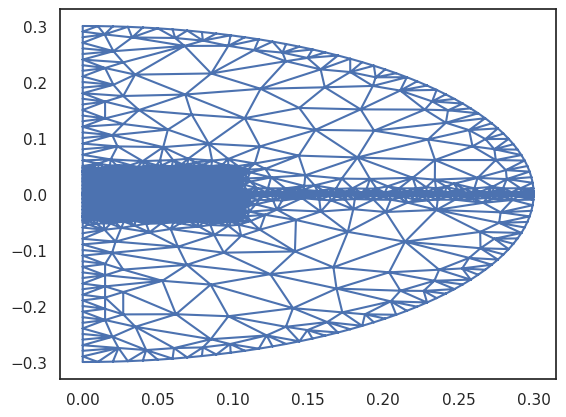

In [78]:
nodes, elements, boundary_edge, boundary_inidces, boundary_elements, outer_curve, inner_curve = mt.LoadTriMesh("Loesung_FEM_WS1920/KlausurWS1920_Netz.npz", show=True)

In [79]:
#______________
# Dirichlet Boundary
def dirichlet_func(x, y):
    return 0

# all knots where r=0
DIRICHLET_INDICES = np.array(mt.RetrieveSegments(nodes, boundary_edge, boundary_inidces, [[0, RA], [0, -RA]], ["Nodes"])).flatten()

#______________
# Robin Boundary
def robin_gamma(x, y):
    mu = _magnetic_pernmability(x, y)
    if np.isclose(x, 0) or np.isclose(y, 0) or np.isclose(mu, 0):  # TODO: this is a hacky solution. handle the robin indicies creation better! 
        return 0
    return 1 / ( mu * x * np.sqrt(np.power(x, 2) + np.power(y, 2)) )

def robin_rhs(x, y):
    return 0

# robin indices should be all segments of the the half circle
BOUNDARY_POINTS = [[0,-RA],[RA, 0],[0,RA]]
ROBIN_INDICES = mt.RetrieveSegments(nodes, boundary_edge, boundary_inidces,BOUNDARY_POINTS, ["Segments", "Segments"])
ROBIN_INDICES = np.concatenate([ROBIN_INDICES[0], ROBIN_INDICES[1]])

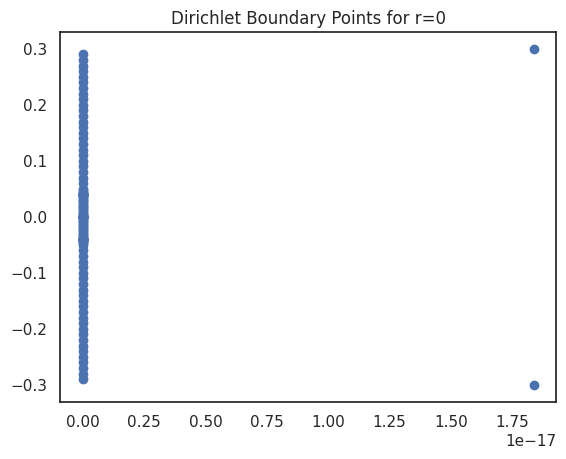

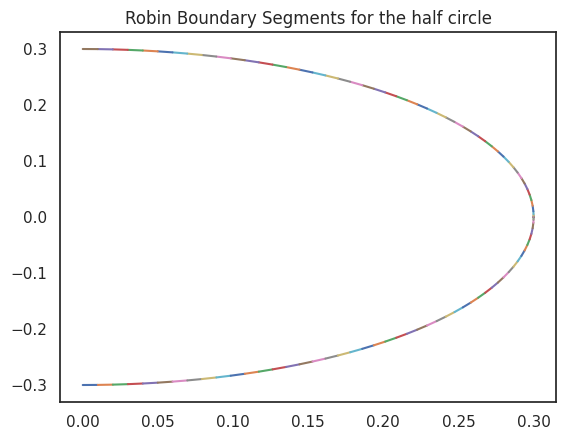

In [ ]:
plt.scatter(nodes[DIRICHLET_INDICES][:,0], nodes[DIRICHLET_INDICES][:,1])

plt.title("Dirichlet Boundary Points for r=0")
plt.show()

fig, ax = plt.subplots()
for segment in nodes[ROBIN_INDICES]:
    x_val = [segment[0,0], segment[1,0]]
    y_val = [segment[0,1], segment[1,1]]

    ax.plot(x_val, y_val)

plt.title("Robin Boundary Segments for the half circle")
plt.show()

## Solve 2D FEM

In [81]:
stiffness_matrix, load_vector = myfunc.assemble_global_system(nodes, elements, alpha1, alpha2, beta, rhs)
stiffness_matrix, load_vector = myfunc.insert_robin_values(nodes, stiffness_matrix, load_vector, ROBIN_INDICES, robin_gamma, robin_rhs)
stiffness_matrix, load_vector = myfunc.insert_dirichlet_values(nodes, stiffness_matrix, load_vector, DIRICHLET_INDICES, dirichlet_func)

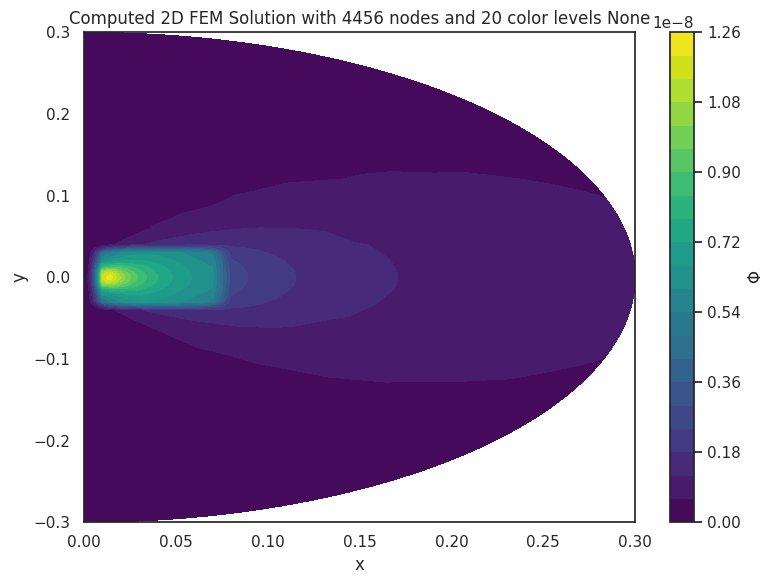

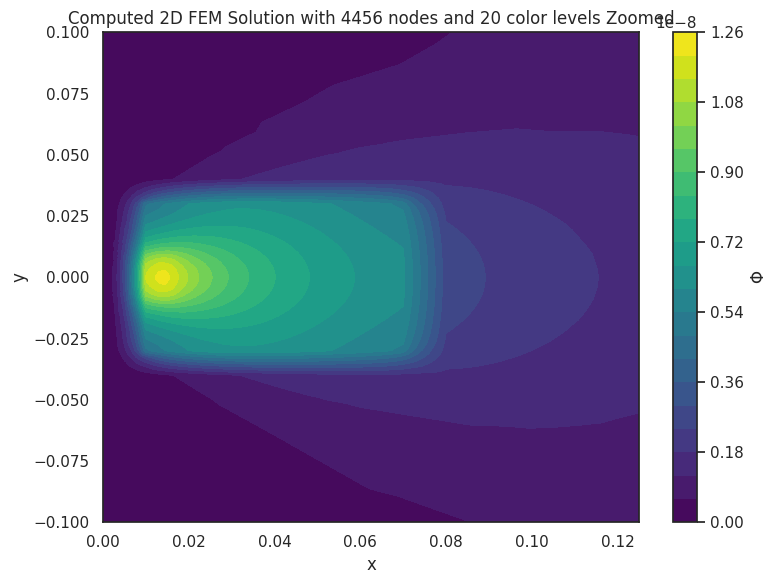

                 x         y           Phi
0     1.836970e-17 -0.300000  0.000000e+00
1     1.002449e-02 -0.299832  8.422193e-13
2     2.003779e-02 -0.299330  3.221778e-12
3     3.002871e-02 -0.298493  6.621276e-12
4     3.998609e-02 -0.297323  1.183223e-11
...            ...       ...           ...
4451  1.247503e-01 -0.143146  4.419472e-10
4452  1.938730e-01  0.113085  6.630061e-10
4453  1.440581e-01  0.153683  4.356991e-10
4454  1.183380e-01  0.187872  2.479652e-10
4455  5.663119e-02  0.114936  2.878598e-10

[4456 rows x 3 columns]


In [82]:
solution = myfunc.solve_system(nodes, stiffness_matrix, load_vector)
myfunc.plot_result(elements, solution, levels=20)

fig, axis = plt.subplots(figsize=(8, 6))
axis.set_xlim(0, 0.125)
axis.set_ylim(-0.1, 0.1)
myfunc.plot_result(elements, solution, levels=20, ax=axis, suffix="Zoomed")
print(solution)

## Calculate Inductance

In [83]:
# Knotenidizes zu [R0,0], [R1,0], [R2,0]
Ps=[[DD,0],[BM-DD,0],[BM,0]]
fnodes=mt.FindClosestNode(range(len(nodes)),nodes,Ps)
node0=fnodes[0][0]
node1=fnodes[0][1]
node2=fnodes[0][2]

In [84]:
def inductance(current, point_1, point_2):

    mask_1 = (
        np.isclose(solution["x"], point_1[0]) &
        np.isclose(solution["y"], point_1[1])
    )
    value_1 = solution.loc[mask_1, "Phi"].values[0]

    mask_2 = (
        np.isclose(solution["x"], point_2[0]) &
        np.isclose(solution["y"], point_2[1])
    )
    value_2 = solution.loc[mask_2, "Phi"].values[0]

    magnetic_flux = 2 * np.pi * (value_1 - value_2)

    return magnetic_flux / current

print(f"Inductance Coil 1: ", inductance(CURRENT_1, nodes[node0], [0,0]))
print("Mutual Inductance: ", inductance(CURRENT_1, nodes[node1], nodes[node2]))

Inductance Coil 1:  7.167690509176669e-08
Mutual Inductance:  2.157323767678666e-08
